In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib widget

In [ ]:
records = [
    # {
    #     'label': 'first pt',
    #     'P': 0,
    #     'time': '11:26',
    # },
    {
        'P': 28.33,
        'tstart': '13:14',
        'time': '13:29',
        'C_avg': 33.5426,
        'P_avg': 28.1898,
    },
    {
        'P': 28.88,
        'tstart':'13:29',
        'time': '13:47',
        'C_avg': 34.7712,
        'P_avg': 28.7299,
    },
    {
        'P': 29.51,
        'tstart': '13:50',
        'time':  '14:01',
        'C_avg': 36.3338,
        'P_avg': 29.3582,
    },
    {
        'P': 30.02,
        'tstart': '14:02',
        'time':  '14:12',
        'C_avg': 37.9147,
        'P_avg': 29.9334,
    },  
    #       
    {
        'P': 30.61,
        'tstart': '14:12',
        'time':  '14:26',
        'C_avg': 39.4996,
        'P_avg': 30.4562,
    },
    {
        'P': 31.09,
        'tstart': '14:28',
        'time':  '14:37',
        'C_avg': 41.0945,
        'P_avg': 30.935,
    },       
    {
        'P': 31.53,
        'tstart': '14:40',
        'time':  '14:52',
        'C_avg': 42.6865,
        'P_avg': 31.371,
    },
    {
        'P': 31.94,
        'tstart': '14:53',
        'time':  '15:07',
        'C_avg': 44.2761,
        'P_avg': 31.769,
    },    
    {
        'P': 32.45,
        'tstart': '15:10',
        'time':  '15:21',
        'C_avg': 46.5843,
        'P_avg': 32.289,
    },                
    {
        'P': 33.03,
        'tstart': '15:22',
        'time':  '15:30',
        'C_avg': 49.4832,
        'P_avg': 32.8599,
    },  
    {
        'P': 33.47,
        'tstart': '15:33',
        'time':  '15:41',
        'C_avg': 52.033,
        'P_avg': 33.297,
    },   
    {
        'P': 33.94,
        'tstart': '15:42',
        'time':  '15:55',
        'C_avg': 55.2025,
        'P_avg': 33.7702,
    },          
    
]

data = pd.read_csv('D:/Data/RNB-Spring2025/Python MCT calibration/DATA_2025-04-17_2.csv', skiprows=9)

In [ ]:

LabView_t0 = 2082844800
timezone = 4 * 60 * 60
data['datetime'] = pd.to_datetime(data['UTC'] - (LabView_t0 + timezone), unit='s')
data.set_index('datetime', inplace=True)

In [ ]:
calib_pts = pd.DataFrame()
for record in records:
    time = record['time']
    time = f'2025-04-17 {time}'
    row = data.loc[time].iloc[0].to_frame().T
    row['C_pick'] = record['C_avg']
    row['P_pick'] = record['P_avg']
    calib_pts = pd.concat([calib_pts, row], axis=0)

calib_pts['C_pick_inv'] = calib_pts['C_pick'] ** -1
calib_pts['C_inv'] = calib_pts['C'] ** -1



In [ ]:
fit_data = calib_pts.loc[calib_pts['P_paro'].between(0, 100)].copy()
xdata = fit_data['C_inv']
ydata = fit_data['P_paro']

popt, pcov = np.polyfit(x=xdata, y=ydata, cov=True, deg=1)

xhat = np.linspace(xdata.min()*0.99, xdata.max()*1.03, 1000)
yhat = np.polyval(popt, xhat)

calib_pts['P_paro_hat'] = np.polyval(popt, calib_pts['C_inv'])
calib_pts['residual'] = calib_pts['P_paro'] - calib_pts['P_paro_hat']

C:\Users\Jeevak\AppData\Local\Temp\ipykernel_22040\760009853.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axa.legend()


Text(0, 0.5, 'P (bar)')

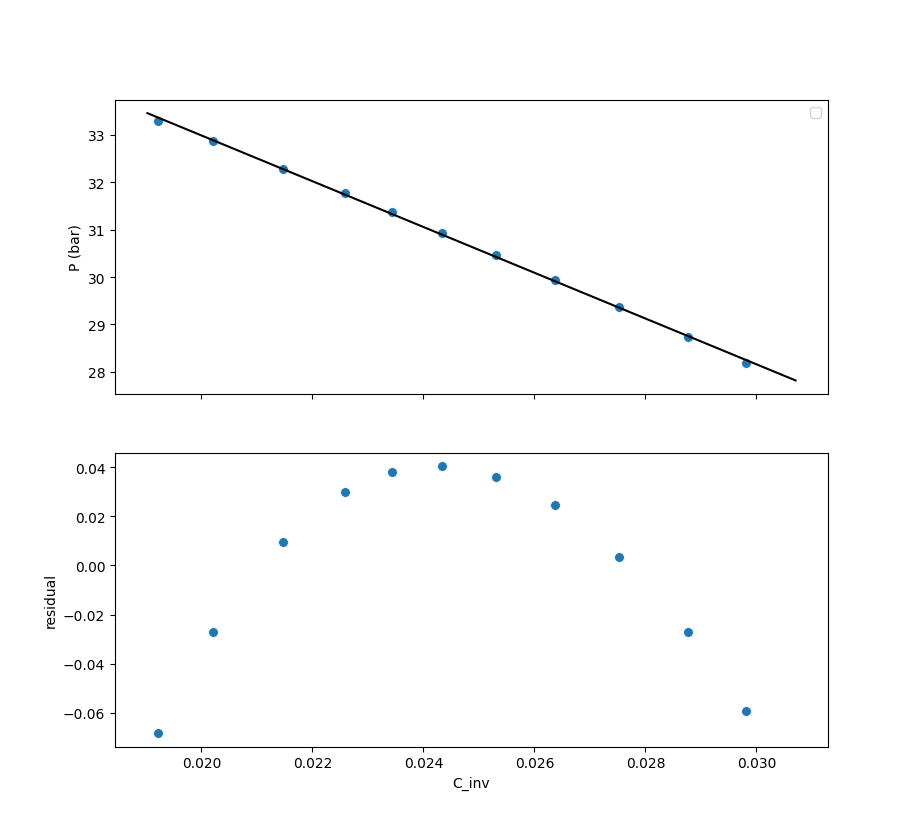

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(9.2, 5.6*1.5), sharex=True)
axa, axb = ax
sns.scatterplot(calib_pts, x='C_inv', y='P_paro', s=50, ax=axa)
axa.plot(xhat, yhat, color='k', linestyle='-', linewidth=1.5)
# sns.scatterplot(calib_pts, x='C_pick_inv', y='P_pick', ax=axa, label='picked pts', s=50)

sns.scatterplot(calib_pts, x='C_inv', y='residual', s=50, ax=axb)
axa.legend()

axa.set_xlabel(r'$1/C$ (pF)$^{-1}$')
axa.set_ylabel(r'P (bar)')